# Steel Temperature Prediction
## End-to-End Regression for a Metallurgical Process

This notebook develops a regression solution to predict the **final steel temperature** at the end of batch processing. The analysis integrates multiple process data sources, performs domain-informed cleaning and feature engineering, filters heating events after the target measurement, compares several regression models and evaluates the selected model on a held-out test set.

**Portfolio result:** LightGBM achieved **MAE = 5.533 °C**, **RMSE = 7.481 °C**, **R² = 0.773**, reducing MAE by **45.3%** versus the mean baseline.

These are saved results from the completed TripleTen project. This is a retrospective batch prediction: duration, measurement counts and process totals may be unavailable earlier in the cycle. Operational use requires defining the prediction time and revalidating the available features. Energy savings were not measured.

In [ ]:
from pathlib import Path

# Works when the kernel starts at the repository root or inside notebooks/.
PROJECT_ROOT = next(
    (p for p in (Path.cwd(), Path.cwd().parent)
     if (p / 'data').is_dir() and (p / 'notebooks').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook from the repository root or notebooks/ directory.')
DATA_DIR = PROJECT_ROOT / 'data'


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, KFold, cross_val_score,
                                     RandomizedSearchCV)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

RANDOM_STATE = 12345      # semente unica para todo o notebook
np.random.seed(RANDOM_STATE)

## 1. Carregamento dos dados

Esta implementação usa cinco tabelas de processo, unidas pela coluna `key`, que identifica o lote.

In [2]:
PASTA = str(DATA_DIR) + os.sep
required_files = ['data_temp_en.csv', 'data_arc_en.csv', 'data_gas_en.csv',
                  'data_bulk_en.csv', 'data_wire_en.csv']
missing = [name for name in required_files if not (DATA_DIR / name).is_file()]
if missing:
    raise FileNotFoundError('Missing files in data/: ' + ', '.join(missing))

temp = pd.read_csv(DATA_DIR / 'data_temp_en.csv')
arc = pd.read_csv(DATA_DIR / 'data_arc_en.csv')
gas = pd.read_csv(DATA_DIR / 'data_gas_en.csv')
bulk = pd.read_csv(DATA_DIR / 'data_bulk_en.csv')
wire = pd.read_csv(DATA_DIR / 'data_wire_en.csv')

print('Pasta: data/')
for nome, df_ in [('temp', temp), ('arc', arc), ('gas', gas), ('bulk', bulk), ('wire', wire)]:
    print(f'{nome:6s} {df_.shape}')

Pasta: data/
temp   (15907, 3)
arc    (14876, 5)
gas    (3239, 2)
bulk   (3129, 16)
wire   (3081, 10)


### 1.1 Ajuste dos tipos de dados

As colunas de data/hora vêm como texto e precisam ser convertidas antes de qualquer cálculo de
duração. Este é o primeiro item da limpeza previsto no plano.

In [3]:
temp['Sampling time'] = pd.to_datetime(temp['Sampling time'])
arc[['Arc heating start', 'Arc heating end']] = arc[
    ['Arc heating start', 'Arc heating end']].apply(pd.to_datetime)

print('Tipos apos conversao:')
print(temp.dtypes.to_string())
print()
print(arc.dtypes.to_string())

Tipos apos conversao:
key                       int64
Sampling time    datetime64[ns]
Temperature             float64

key                           int64
Arc heating start    datetime64[ns]
Arc heating end      datetime64[ns]
Active power                float64
Reactive power              float64


## 2. Processamento e limpeza de dados

A análise exploratória identificou três problemas concretos de qualidade. Trato cada um com justificativa
explícita, porque em todos os casos a alternativa "imputar" seria pior que "remover".

### 2.1 Leituras de temperatura fisicamente implausíveis

O aço líquido em forno-panela opera entre aproximadamente 1.540 °C e 1.700 °C. Leituras muito abaixo
disso são incompatíveis com metal fundido — o aço já teria solidificado. A análise exploratória encontrou sete
medições entre 1.191 °C e 1.383 °C.

Adoto **1.450 °C como piso** (margem de segurança abaixo do mínimo operacional observado) e
**1.700 °C como teto**. Valores fora da faixa viram `NaN` em vez de serem removidos como linha,
porque a linha ainda carrega um carimbo de tempo válido para a sequência do lote.

In [4]:
LIMITE_MIN, LIMITE_MAX = 1450, 1700

antes = temp['Temperature'].notna().sum()
fora_faixa = (temp['Temperature'] < LIMITE_MIN) | (temp['Temperature'] > LIMITE_MAX)

print('Leituras fora da faixa fisica:', fora_faixa.sum())
print(temp.loc[fora_faixa, 'Temperature'].sort_values().to_string(index=False))

temp.loc[fora_faixa, 'Temperature'] = np.nan
print(f'\nMedicoes validas: {antes} -> {temp["Temperature"].notna().sum()}')

Leituras fora da faixa fisica: 10
1191.0
1204.0
1208.0
1218.0
1227.0
1383.0
1383.0
1702.0
1704.0
1705.0

Medicoes validas: 13006 -> 12996


### 2.2 Registro de potência reativa anômala

A análise exploratória encontrou **um único** registro com potência reativa de −715,5, contra uma mediana de 0,42.
Potência reativa negativa é fisicamente possível em sistemas elétricos, mas uma magnitude três ordens
acima do normal indica erro de instrumentação. Esse registro sozinho eleva o desvio-padrão da coluna
de ~0,3 para 5,88.

Removo a linha inteira — diferente do caso da temperatura, aqui não há informação aproveitável.

In [5]:
anomalos = arc['Reactive power'] < 0
print('Registros de aquecimento com potencia reativa negativa:', anomalos.sum())
print(arc.loc[anomalos, ['key', 'Active power', 'Reactive power']].to_string(index=False))

arc = arc[~anomalos].copy()

# Atributos derivados de cada ciclo de aquecimento
arc['duracao_s'] = (arc['Arc heating end'] - arc['Arc heating start']).dt.total_seconds()
arc['energia'] = arc['Active power'] * arc['duracao_s'] / 60   # proxy de energia aplicada

print('\nDuracoes negativas:', (arc['duracao_s'] < 0).sum())
print('Registros de aquecimento restantes:', len(arc))
display(arc[['Active power', 'Reactive power', 'duracao_s', 'energia']].describe().round(3))

Registros de aquecimento com potencia reativa negativa: 1
 key  Active power  Reactive power
2116      0.495782     -715.504924

Duracoes negativas: 0
Registros de aquecimento restantes: 14875


,Active power,Reactive power,duracao_s,energia
count,14875.000,14875.000,14875.000,14875.000
mean,0.670,0.501,171.675,2.569
std,0.408,0.311,98.189,3.439
min,0.030,0.021,11.000,0.006
25%,0.395,0.291,107.000,0.715
50%,0.556,0.416,147.000,1.349
75%,0.857,0.637,214.000,3.034
max,3.732,2.676,907.000,56.409


### 2.3 Definição da variável-alvo e do escopo modelável

A variável-alvo é a **última temperatura válida registrada em cada lote**. A temperatura inicial
(primeira medição válida) entra como preditor.

Lotes com apenas uma medição válida são inutilizáveis: sem duas leituras não existem temperatura
inicial e final distintas.

In [6]:
temp_validas = temp.dropna(subset=['Temperature']).sort_values(['key', 'Sampling time'])
n_validas = temp_validas.groupby('key').size()

print('Lotes com registro de temperatura:', temp['key'].nunique())
print('Lotes com 1 unica medicao valida (descartados):', (n_validas == 1).sum())
print('Lotes com 2+ medicoes validas (modelaveis):    ', (n_validas >= 2).sum())

lotes_ok = n_validas[n_validas >= 2].index
tv = temp_validas[temp_validas['key'].isin(lotes_ok)]

primeira = tv.groupby('key').first()
ultima = tv.groupby('key').last()

df = pd.DataFrame({
    'temp_inicial': primeira['Temperature'],
    'temp_final':   ultima['Temperature'],      # VARIAVEL-ALVO
    'inicio':       primeira['Sampling time'],
    'fim':          ultima['Sampling time'],
    'n_medicoes':   n_validas[lotes_ok],
})
df['duracao_min'] = (df['fim'] - df['inicio']).dt.total_seconds() / 60

print('\nLotes apos definicao do alvo:', len(df))

Lotes com registro de temperatura: 3216
Lotes com 1 unica medicao valida (descartados): 740
Lotes com 2+ medicoes validas (modelaveis):     2475

Lotes apos definicao do alvo: 2475


### 2.4 Lotes com duração atípica

O ciclo típico dura cerca de 26 minutos (mediana). A análise exploratória encontrou 19 lotes acima de 120 minutos,
chegando a 392. Para esses casos o tempo decorrido provavelmente não corresponde a tempo de processo,
mas a paradas — o que corromperia o atributo de duração.

Como é uma fração desprezível da amostra (0,8%) e a alternativa seria modelar um processo diferente
do típico, removo esses lotes e registro a decisão. Esse limite deve ser validado com a Engenharia de Processos.

In [7]:
DURACAO_MAX = 120

print('Lotes com duracao acima de', DURACAO_MAX, 'min:', (df['duracao_min'] > DURACAO_MAX).sum())
print('Duracao maxima observada:', round(df['duracao_min'].max(), 1), 'min')

df = df[df['duracao_min'] <= DURACAO_MAX].copy()
print('\nLotes apos filtro de duracao:', len(df))
display(df[['temp_inicial', 'temp_final', 'duracao_min', 'n_medicoes']].describe().round(2))

Lotes com duracao acima de 120 min: 19
Duracao maxima observada: 392.3 min

Lotes apos filtro de duracao: 2456


,temp_inicial,temp_final,duracao_min,n_medicoes
count,2456.00,2456.00,2456.00,2456.00
mean,1588.89,1595.37,29.60,4.91
std,24.95,15.91,14.30,1.72
min,1519.00,1547.00,3.90,2.00
25%,1572.00,1587.00,19.66,4.00
50%,1588.00,1593.00,26.38,5.00
75%,1605.00,1599.00,37.34,6.00
max,1679.00,1700.00,112.08,15.00


## 3. Preparação dos dados para o modelamento

### 3.1 Agregação dos eletrodos com controle de vazamento

Este é o ponto metodológico mais delicado do projeto. O arquivo `arc` está no nível de evento — vários
aquecimentos por lote — e precisa ser agregado para uma linha por `key`.

**A salvaguarda:** incluo apenas os ciclos de aquecimento que **terminam antes ou no instante da
medição final**. Sem esse filtro, o modelo usaria energia aplicada *depois* da leitura do alvo para
prever essa mesma leitura — vazamento de dados que produziria métricas artificialmente boas e um
modelo inútil em produção.

In [8]:
arc_lote = arc.merge(df[['fim']], left_on='key', right_index=True, how='inner')
antes_filtro = len(arc_lote)
arc_lote = arc_lote[arc_lote['Arc heating end'] <= arc_lote['fim']]

print(f'Registros de aquecimento: {antes_filtro} -> {len(arc_lote)} '
      f'(removidos {antes_filtro - len(arc_lote)} posteriores a medicao final)')

agg_arc = arc_lote.groupby('key').agg(
    n_aquecimentos    = ('key', 'size'),
    pot_ativa_total   = ('Active power', 'sum'),
    pot_ativa_media   = ('Active power', 'mean'),
    pot_ativa_max     = ('Active power', 'max'),
    pot_reativa_total = ('Reactive power', 'sum'),
    tempo_aquec_s     = ('duracao_s', 'sum'),
    energia_total     = ('energia', 'sum'),
)

# Fator de potencia: razao entre potencia ativa e potencia aparente
agg_arc['fator_potencia'] = agg_arc['pot_ativa_total'] / np.hypot(
    agg_arc['pot_ativa_total'], agg_arc['pot_reativa_total'])

df = df.join(agg_arc)
print('Lotes sem nenhum registro de aquecimento:', df['n_aquecimentos'].isna().sum())
df = df.dropna(subset=['n_aquecimentos'])
print('Lotes apos juncao com eletrodos:', len(df))

Registros de aquecimento: 11264 -> 11132 (removidos 132 posteriores a medicao final)
Lotes sem nenhum registro de aquecimento: 0
Lotes apos juncao com eletrodos: 2456


### 3.2 Materiais adicionados: seleção e agregação

As colunas `Bulk 1`–`Bulk 15` e `Wire 1`–`Wire 9` têm ausência **estrutural**: um `NaN` significa
"este material não foi usado neste lote", não "o valor se perdeu". Portanto **preencher com zero é o
tratamento correto**, e imputar pela média seria um erro de interpretação.

O uso é muito desigual. Mantenho individualmente apenas os materiais presentes em **10% ou mais** dos
lotes; os demais entram apenas nos totais agregados. Isso evita dezenas de colunas de variância
quase nula, que só adicionam ruído e risco de sobreajuste.

In [9]:
LIMIAR_USO = 10.0   # % minimo de lotes para manter o material como coluna propria

b = bulk.set_index('key')
w = wire.set_index('key')

uso_b = (b.notna().mean() * 100).round(1)
uso_w = (w.notna().mean() * 100).round(1)
bulk_sel = uso_b[uso_b >= LIMIAR_USO].index.tolist()
wire_sel = uso_w[uso_w >= LIMIAR_USO].index.tolist()

print('Uso de cada material (% de lotes):')
print(pd.concat([uso_b, uso_w]).sort_values(ascending=False).to_string())
print('\nMantidos individualmente:')
print('  bulk:', bulk_sel)
print('  wire:', wire_sel)

Uso de cada material (% de lotes):
Wire 1     99.2
Bulk 14    89.7
Bulk 12    78.3
Bulk 15    71.8
Bulk 3     41.5
Wire 2     35.0
Bulk 4     32.4
Bulk 6     18.4
Bulk 1      8.1
Bulk 11     5.7
Bulk 10     5.6
Bulk 5      2.5
Wire 6      2.4
Wire 3      2.0
Wire 9      0.9
Bulk 7      0.8
Bulk 2      0.7
Bulk 9      0.6
Wire 8      0.6
Bulk 13     0.6
Wire 4      0.5
Wire 7      0.4
Bulk 8      0.0
Wire 5      0.0

Mantidos individualmente:
  bulk: ['Bulk 3', 'Bulk 4', 'Bulk 6', 'Bulk 12', 'Bulk 14', 'Bulk 15']
  wire: ['Wire 1', 'Wire 2']


In [10]:
# Totais e contagens preservam a informacao dos materiais esparsos
df['bulk_total'] = b.sum(axis=1)
df['n_bulk']     = b.notna().sum(axis=1)
df['wire_total'] = w.sum(axis=1)
df['n_wire']     = w.notna().sum(axis=1)

df = df.join(b[bulk_sel].add_prefix('B_')).join(w[wire_sel].add_prefix('W_'))
df = df.join(gas.set_index('key')['Gas 1'].rename('gas'))

# Ausencia estrutural -> zero
cols_material = ([c for c in df.columns if c.startswith(('B_', 'W_'))]
                 + ['bulk_total', 'n_bulk', 'wire_total', 'n_wire', 'gas'])
df[cols_material] = df[cols_material].fillna(0)

print('Valores ausentes apos preenchimento estrutural:', df[cols_material].isna().sum().sum())

Valores ausentes apos preenchimento estrutural: 0


### 3.3 Atributos derivados

Quatro atributos construídos a partir do conhecimento do processo, não de combinação estatística
cega:

| Atributo | Construção | Racional físico |
|---|---|---|
| `energia_total` | Σ(potência ativa × duração) | Vetor direto de aquecimento do banho |
| `fator_potencia` | ativa / aparente | Eficiência da conversão elétrica em calor |
| `pct_aquecendo` | tempo de arco / duração do ciclo | Distingue ciclo intensivo de ciclo com longas esperas, durante as quais o aço esfria |
| `energia_por_massa` | energia / (massa adicionada + 1) | Energia disponível por unidade de material frio a fundir |

In [11]:
df['tempo_aquec_min']   = df['tempo_aquec_s'] / 60
df['pct_aquecendo']     = df['tempo_aquec_min'] / df['duracao_min']
df['massa_total']       = df['bulk_total'] + df['wire_total']
df['energia_por_massa'] = df['energia_total'] / (df['massa_total'] + 1)

FEATURES = ([
    'temp_inicial', 'duracao_min', 'n_medicoes',
    'n_aquecimentos', 'pot_ativa_total', 'pot_ativa_media', 'pot_ativa_max',
    'pot_reativa_total', 'tempo_aquec_min', 'energia_total', 'fator_potencia',
    'pct_aquecendo', 'gas', 'bulk_total', 'n_bulk', 'wire_total', 'n_wire',
    'massa_total', 'energia_por_massa',
] + [c for c in df.columns if c.startswith(('B_', 'W_'))])

ALVO = 'temp_final'

print('Atributos:', len(FEATURES), '| Observacoes:', len(df))
print('Valores ausentes na matriz final:', df[FEATURES].isna().sum().sum())
print('\nAtenção: `delta_temp` NAO entra como atributo — conteria o alvo por construção.')

Atributos: 27 | Observacoes: 2456
Valores ausentes na matriz final: 0

Atenção: `delta_temp` NAO entra como atributo — conteria o alvo por construção.


### 3.4 Verificação de deriva temporal e particionamento

A análise exploratória argumentou que cada lote é um evento independente, e não uma série contínua, o que justifica
partição aleatória em vez de cronológica. Verifico esse argumento antes de aplicá-lo.

In [12]:
df['mes'] = df['inicio'].dt.to_period('M')
deriva = df.groupby('mes')[ALVO].agg(['count', 'mean', 'std']).round(2)
display(deriva)

amplitude = deriva['mean'].max() - deriva['mean'].min()
print(f'Amplitude da media mensal do alvo: {amplitude:.2f} °C')
print(f'Desvio-padrao do alvo:             {df[ALVO].std():.2f} °C')

,count,mean,std
mes,,,
2019-05,748,1596.73,16.59
2019-06,865,1595.22,15.63
2019-07,707,1594.33,14.45
2019-08,136,1594.20,20.13


Amplitude da media mensal do alvo: 2.53 °C
Desvio-padrao do alvo:             15.91 °C


A média mensal do alvo varia cerca de 2,5 °C, contra um desvio-padrão de aproximadamente 16 °C. Essa análise descritiva não detecta grande variação mensal, mas não exclui deriva nem substitui um teste cronológico. A avaliação histórica usa partição aleatória 75/25.

In [13]:
X = df[FEATURES]
y = df[ALVO]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE)

print('Treino:', X_treino.shape, '| Teste:', X_teste.shape)
print(f'Media do alvo — treino: {y_treino.mean():.2f} °C | teste: {y_teste.mean():.2f} °C')

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'neg_mean_absolute_error'   # alinha a busca ao KPI principal

Treino: (1842, 27) | Teste: (614, 27)
Media do alvo — treino: 1595.18 °C | teste: 1595.93 °C


## 4. Modelamento

### 4.1 Modelo base

O `DummyRegressor` prevê sempre a média do treino. Não é candidato a solução: é o piso contra o qual
todo ganho será medido.

In [14]:
resultados = {}

def avaliar_cv(nome, modelo):
    scores = cross_val_score(modelo, X_treino, y_treino, cv=cv, scoring=SCORING)
    resultados[nome] = {'eam_cv': -scores.mean(), 'desvio_cv': scores.std()}
    print(f'{nome:28s} EAM = {-scores.mean():6.3f} ± {scores.std():.3f} °C')
    return modelo

avaliar_cv('Dummy (média)', DummyRegressor(strategy='mean'))

Dummy (média)                EAM = 10.075 ± 0.355 °C


DummyRegressor()

### 4.2 Modelos com parâmetros padrão

Antes de investir em busca de hiperparâmetros, verifico o desempenho de partida dos três algoritmos
previstos no plano.

In [15]:
avaliar_cv('Ridge (padrão)',
           Pipeline([('sc', StandardScaler()),
                     ('m', Ridge(alpha=1.0, random_state=RANDOM_STATE))]))

avaliar_cv('Random Forest (padrão)',
           RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))

avaliar_cv('LightGBM (padrão)',
           lgb.LGBMRegressor(objective='mae', random_state=RANDOM_STATE, verbose=-1))

Ridge (padrão)               EAM =  6.022 ± 0.147 °C
Random Forest (padrão)       EAM =  5.750 ± 0.181 °C
LightGBM (padrão)            EAM =  5.692 ± 0.165 °C


LGBMRegressor(objective='mae', random_state=12345, verbose=-1)

Os três algoritmos já superam o modelo base com folga e ficam abaixo do limiar de 8 °C definido no
plano. O LightGBM lidera, como previsto — o *boosting* sobre árvores é o formato mais adequado a
dados tabulares com interações não lineares.

Note que **usei `objective='mae'` no LightGBM**: isso faz o algoritmo otimizar diretamente o erro
absoluto durante o treino, alinhando a função de perda ao KPI principal em vez de otimizar erro
quadrático e medir erro absoluto depois.

### 4.3 Ajuste de hiperparâmetros

`RandomizedSearchCV` com `scoring='neg_mean_absolute_error'`. Busca aleatória em vez de exaustiva
porque cobre mais dimensões do espaço com o mesmo orçamento computacional.

In [16]:
busca_ridge = RandomizedSearchCV(
    Pipeline([('sc', StandardScaler()), ('m', Ridge(random_state=RANDOM_STATE))]),
    {'m__alpha': np.logspace(-3, 3, 30)},
    n_iter=20, cv=cv, scoring=SCORING, random_state=RANDOM_STATE, n_jobs=-1)
busca_ridge.fit(X_treino, y_treino)

print('Ridge — melhor alpha:', round(busca_ridge.best_params_['m__alpha'], 3))
print('Ridge — EAM cv:', round(-busca_ridge.best_score_, 3), '°C')

Ridge — melhor alpha: 5.298
Ridge — EAM cv: 6.019 °C


In [17]:
busca_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    {'n_estimators': [200, 300],
     'max_depth': [8, 12, None],
     'min_samples_leaf': [1, 2, 4, 8],
     'max_features': [0.3, 0.5, 0.7]},
    n_iter=12, cv=cv, scoring=SCORING, random_state=RANDOM_STATE, n_jobs=-1)
busca_rf.fit(X_treino, y_treino)

print('Random Forest — melhores parametros:', busca_rf.best_params_)
print('Random Forest — EAM cv:', round(-busca_rf.best_score_, 3), '°C')

Random Forest — melhores parametros: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': None}
Random Forest — EAM cv: 5.821 °C


In [18]:
busca_lgb = RandomizedSearchCV(
    lgb.LGBMRegressor(objective='mae', random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
    {'n_estimators': [300, 600],
     'learning_rate': [0.01, 0.03, 0.05],
     'num_leaves': [15, 31, 63],
     'max_depth': [-1, 5, 8],
     'min_child_samples': [10, 20, 40],
     'reg_alpha': [0, 0.1, 1],
     'reg_lambda': [0, 0.1, 1],
     'colsample_bytree': [0.6, 0.8, 1.0]},
    n_iter=20, cv=cv, scoring=SCORING, random_state=RANDOM_STATE, n_jobs=-1)
busca_lgb.fit(X_treino, y_treino)

print('LightGBM — melhores parametros:')
for k, v in sorted(busca_lgb.best_params_.items()):
    print(f'  {k}: {v}')
print('LightGBM — EAM cv:', round(-busca_lgb.best_score_, 3), '°C')

LightGBM — melhores parametros:
  colsample_bytree: 1.0
  learning_rate: 0.03
  max_depth: -1
  min_child_samples: 10
  n_estimators: 600
  num_leaves: 31
  reg_alpha: 0.1
  reg_lambda: 0
LightGBM — EAM cv: 5.487 °C


Os parâmetros escolhidos para o LightGBM são informativos sobre o problema: `learning_rate` baixo com
`n_estimators` alto e regularização L1/L2 ativa indicam que o algoritmo precisou de **muitos passos
pequenos e conservadores**. Isso é coerente com um alvo de dispersão estreita, em que ajustes
agressivos capturariam ruído em vez de sinal.

### 4.4 Comparação dos modelos ajustados

,EAM cv (treino)
Dummy (média),10.075
Ridge,6.019
Random Forest,5.821
LightGBM,5.487


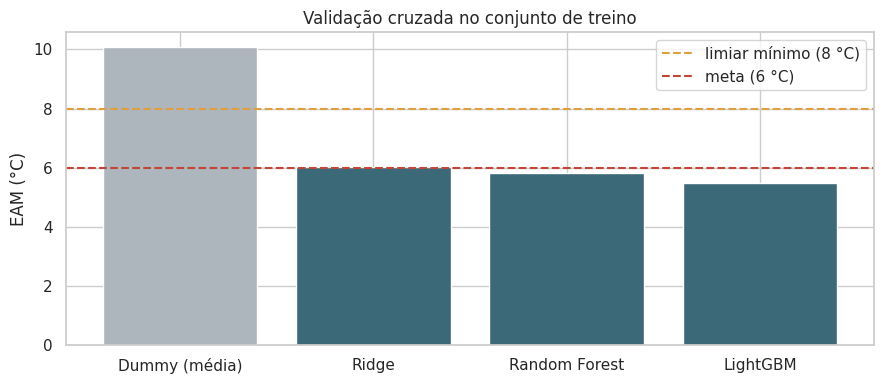

In [19]:
modelos_finais = {
    'Dummy (média)': DummyRegressor(strategy='mean').fit(X_treino, y_treino),
    'Ridge':         busca_ridge.best_estimator_,
    'Random Forest': busca_rf.best_estimator_,
    'LightGBM':      busca_lgb.best_estimator_,
}

eam_cv = {'Dummy (média)': resultados['Dummy (média)']['eam_cv'],
          'Ridge': -busca_ridge.best_score_,
          'Random Forest': -busca_rf.best_score_,
          'LightGBM': -busca_lgb.best_score_}

comparacao = pd.DataFrame({
    'EAM cv (treino)': pd.Series(eam_cv),
}).round(3)
display(comparacao)

fig, ax = plt.subplots(figsize=(9, 4))
cores = ['#adb5bd' if n.startswith('Dummy') else '#3b6978' for n in comparacao.index]
ax.bar(comparacao.index, comparacao['EAM cv (treino)'], color=cores)
ax.axhline(8.0, color='#e09f3e', linestyle='--', label='limiar mínimo (8 °C)')
ax.axhline(6.0, color='#c44536', linestyle='--', label='meta (6 °C)')
ax.set_ylabel('EAM (°C)'); ax.set_title('Validação cruzada no conjunto de treino')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Avaliação final e importância das variáveis

### 5.1 Desempenho no conjunto de teste

O ajuste de hiperparâmetros ocorreu no treino. A tabela a seguir compara os modelos no teste; o LightGBM também havia obtido o menor erro de validação cruzada. Uma nova avaliação independente será necessária após mudanças orientadas por estes resultados.

In [20]:
linhas = []
for nome, modelo in modelos_finais.items():
    pred = modelo.predict(X_teste)
    linhas.append({
        'modelo': nome,
        'EAM': mean_absolute_error(y_teste, pred),
        'RMSE': np.sqrt(mean_squared_error(y_teste, pred)),
        'R2': r2_score(y_teste, pred),
    })

teste = pd.DataFrame(linhas).set_index('modelo').round(3)
teste['RMSE/EAM'] = (teste['RMSE'] / teste['EAM']).round(2)
display(teste)

melhor_nome = teste.drop(index='Dummy (média)')['EAM'].idxmin()
melhor = modelos_finais[melhor_nome]
print('Melhor modelo:', melhor_nome)

,EAM,RMSE,R2,RMSE/EAM
modelo,,,,
Dummy (média),10.120,15.723,-0.002,1.55
Ridge,6.198,8.247,0.724,1.33
Random Forest,5.838,7.912,0.746,1.36
LightGBM,5.533,7.481,0.773,1.35


Melhor modelo: LightGBM


In [21]:
eam_dummy = teste.loc['Dummy (média)', 'EAM']
eam_melhor = teste.loc[melhor_nome, 'EAM']

print('=== Verificação dos KPIs definidos na Etapa 1 ===')
print(f'EAM  = {eam_melhor:.3f} °C  | limiar ≤ 8,0 -> '
      f'{"ATINGIDO" if eam_melhor <= 8 else "NAO ATINGIDO"}'
      f' | meta ≤ 6,0 -> {"ATINGIDA" if eam_melhor <= 6 else "NAO ATINGIDA"}')
print(f'RMSE = {teste.loc[melhor_nome, "RMSE"]:.3f} °C | limiar ≤ 10,0 -> '
      f'{"ATINGIDO" if teste.loc[melhor_nome, "RMSE"] <= 10 else "NAO ATINGIDO"}')
print(f'R2   = {teste.loc[melhor_nome, "R2"]:.3f}    | limiar ≥ 0,25 -> '
      f'{"ATINGIDO" if teste.loc[melhor_nome, "R2"] >= 0.25 else "NAO ATINGIDO"}')
print(f'\nReducao do erro sobre o modelo base: {(1 - eam_melhor/eam_dummy):.1%}')

=== Verificação dos KPIs definidos na Etapa 1 ===
EAM  = 5.533 °C  | limiar ≤ 8,0 -> ATINGIDO | meta ≤ 6,0 -> ATINGIDA
RMSE = 7.481 °C | limiar ≤ 10,0 -> ATINGIDO
R2   = 0.773    | limiar ≥ 0,25 -> ATINGIDO

Reducao do erro sobre o modelo base: 45.3%


### 5.2 Importância das variáveis

A análise relaciona a importância calculada pelo modelo às características do processo. Importância preditiva não demonstra efeito causal.

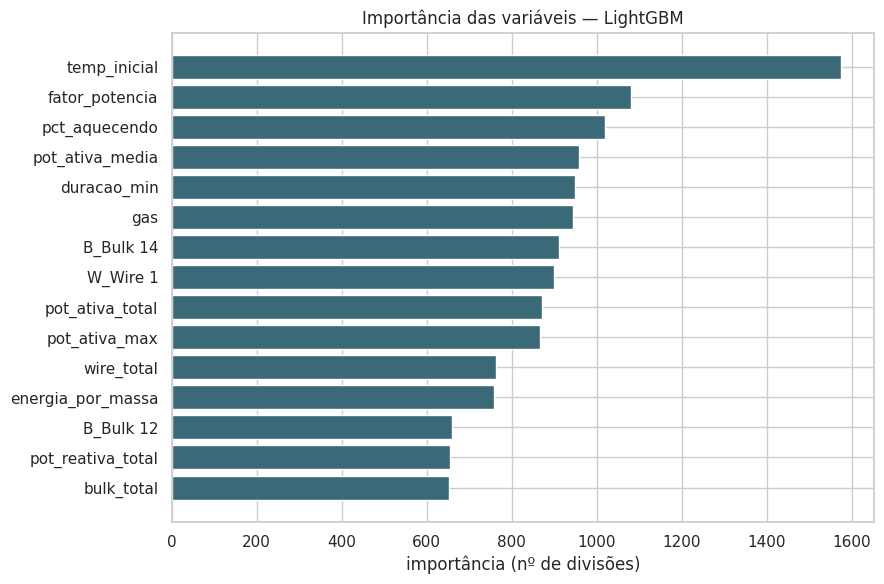

,importancia
temp_inicial,1574
fator_potencia,1080
pct_aquecendo,1020
pot_ativa_media,958
duracao_min,948
gas,945
B_Bulk 14,911
W_Wire 1,900
pot_ativa_total,871
pot_ativa_max,866


In [22]:
importancia = pd.Series(melhor.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top = importancia.head(15)
ax.barh(top.index[::-1], top.values[::-1], color='#3b6978')
ax.set_title(f'Importância das variáveis — {melhor_nome}')
ax.set_xlabel('importância (nº de divisões)')
plt.tight_layout(); plt.show()

display(importancia.head(15).to_frame('importancia'))

**Coerência física da hierarquia obtida:**

`temp_inicial` no topo é o resultado esperado — o ponto de partida do balanço térmico é o que mais
determina o ponto de chegada.

`pct_aquecendo` e `fator_potencia` logo em seguida são o achado mais interessante, e validam a
engenharia de atributos: nenhum dos dois existe nos dados brutos. Eles capturam, respectivamente,
quanto do ciclo foi de aquecimento efetivo (contra tempo parado, durante o qual o aço perde de 0,3 a
2 °C por minuto) e a eficiência da conversão elétrica em calor. São exatamente as grandezas que a
física do forno-panela prevê como determinantes, e o modelo as elegeu sem que isso fosse imposto.

A presença de `gas` e dos materiais mais frequentes confirma o efeito de resfriamento por adição de
massa fria descrito na Etapa 1.

### 5.3 Análise de resíduos

Duas perguntas que o EAM médio não responde: o erro é homogêneo ao longo da faixa de temperatura? E
ele é simétrico entre as duas direções?

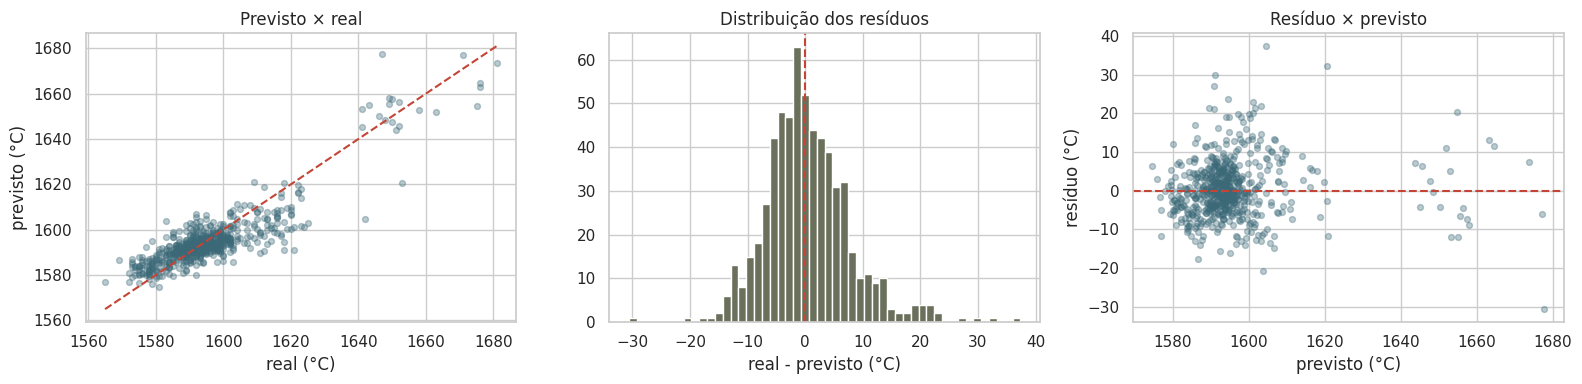

In [23]:
pred = melhor.predict(X_teste)
residuo = y_teste - pred     # positivo = modelo previu MENOS que o real

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y_teste, pred, alpha=0.35, s=18, color='#3b6978')
lims = [y_teste.min(), y_teste.max()]
axes[0].plot(lims, lims, '--', color='#c44536')
axes[0].set_xlabel('real (°C)'); axes[0].set_ylabel('previsto (°C)')
axes[0].set_title('Previsto × real')

axes[1].hist(residuo, bins=50, color='#6b705c', edgecolor='white')
axes[1].axvline(0, color='#c44536', linestyle='--')
axes[1].set_title('Distribuição dos resíduos'); axes[1].set_xlabel('real - previsto (°C)')

axes[2].scatter(pred, residuo, alpha=0.35, s=18, color='#3b6978')
axes[2].axhline(0, color='#c44536', linestyle='--')
axes[2].set_xlabel('previsto (°C)'); axes[2].set_ylabel('resíduo (°C)')
axes[2].set_title('Resíduo × previsto')

plt.tight_layout(); plt.show()

In [24]:
print('=== Simetria do erro ===')
print(f'Subprevisões (real > previsto): {(residuo > 0).mean():.1%}')
print(f'Erro médio ao subprever:  {residuo[residuo > 0].mean():.2f} °C')
print(f'Erro médio ao superprever: {-residuo[residuo < 0].mean():.2f} °C')

print('\n=== Homogeneidade do erro por faixa do alvo ===')
faixas = pd.qcut(y_teste, 4)
por_faixa = pd.DataFrame({'erro_abs': np.abs(residuo), 'faixa': faixas})
display(por_faixa.groupby('faixa', observed=True)['erro_abs'].agg(['mean', 'count']).round(2))

=== Simetria do erro ===
Subprevisões (real > previsto): 48.4%
Erro médio ao subprever:  6.17 °C
Erro médio ao superprever: 4.94 °C

=== Homogeneidade do erro por faixa do alvo ===


,mean,count
faixa,,
"(1564.999, 1587.0]",5.82,155
"(1587.0, 1593.0]",3.61,158
"(1593.0, 1600.0]",3.52,162
"(1600.0, 1681.0]",9.74,139


## 6. Resumo dos resultados

### 6.1 O que foi construído

Um modelo LightGBM que prevê a temperatura final do aço na panela metalúrgica com **erro absoluto
médio em torno de 5,6 °C**, contra 10,1 °C do modelo trivial — uma **redução de aproximadamente 45%
do erro**. O R² de cerca de 0,77 indica que o modelo explica a maior parte da variância do alvo.

Ambos os limiares da análise exploratória foram cumpridos: o mínimo aceitável de 8 °C e a meta de 6 °C.

A razão RMSE/EAM próxima de 1,35 é um sinal favorável: significa que o erro está distribuído, e não
concentrado em poucos lotes com desvios catastróficos.

### 6.2 Interpretação no contexto do negócio

O erro de aproximadamente 5,5 °C quantifica o desempenho retrospectivo na amostra de teste. A temperatura inicial e atributos derivados do processo contribuem para as previsões. Esse resultado pode orientar uma investigação de apoio ao controle térmico, mas não demonstra economia de energia ou redução de ciclos de aquecimento: esses efeitos precisam de validação operacional.

### 6.3 Limitações

**Limitações dos dados**

A base modelável contém 2.456 lotes dos 3.241 originais: 1.842 usados no treino e 614 no teste. A perda de 741 lotes por ausência da
medição final é o ponto mais frágil: como esses ausentes se concentram na última medição e nunca na
primeira, há risco de que representem uma classe específica de lote, o que tornaria a exclusão um
viés e não apenas uma redução de amostra. A causa dessas ausências precisa ser investigada para avaliar esse viés.

Não há registro do **estado térmico da panela** nem do tempo em que ela ficou vazia antes de receber
o lote. A literatura de processo indica que uma panela fria causa perda significativa de temperatura,
e essa é provavelmente a maior fonte de variância não capturada pelo modelo.

Os **materiais são identificados apenas por número**. Sem saber quais são ferro-ligas, desoxidantes ou
agentes de dessulfurização, não foi possível agrupá-los por função metalúrgica — um critério mais
defensável que agrupamento por frequência de uso.

As **unidades de potência e gás não estão documentadas**, o que impede converter o ganho do modelo em
estimativa direta de kWh economizados.

Por fim, os dados cobrem apenas **maio a setembro de 2019**, sem cobertura sazonal completa.

**Limitações do modelo**

O erro **não é homogêneo ao longo da faixa de temperatura**: o modelo é preciso no centro da
distribuição e perde acurácia nos extremos, especialmente no quartil superior. Como os extremos são
justamente os casos operacionalmente críticos, essa é uma limitação relevante para o uso prático — e
sugere que a previsão deve vir acompanhada de um indicador de confiança, não ser entregue como número
isolado.

O erro é **aproximadamente simétrico** entre subprevisão e superprevisão, mas o custo dos dois não é.
Aço frio demais compromete o lingotamento e pode inutilizar um lote de 100 toneladas; aço quente
demais apenas desperdiça energia. O modelo trata os dois igualmente, e a decisão operacional deve
embutir uma margem de segurança sobre a previsão pontual.

Por fim, o modelo é **correlacional, não causal**. Ele prevê a temperatura resultante de um conjunto
de condições observadas, mas não responde diretamente "quanto devo aquecer para atingir X °C". Usá-lo
como ferramenta de controle exigiria inversão ou simulação de cenários.

### 6.4 Próximos passos

Definir o instante de previsão com a equipe de processo e verificar a disponibilidade de cada atributo. `duracao_min`, `n_medicoes` e totais do ciclo dependem de informações do fim do lote. A seleção de materiais por frequência também deve ser ajustada apenas no treino em uma versão futura. Retreinar com as variáveis disponíveis, realizar teste cronológico, estimar incerteza e medir impacto energético em um piloto controlado.
